# Data Presentation
Empirical hazard rates with 95% confidence intervals from administrative data.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [25]:
# ── U→E and U→S: integer months, 0-indexed (anc_ved_afgang=0 → month 1) ──────
_ue = pd.read_csv('hazard_UE.csv')
_us = pd.read_csv('hazard_US.csv')
_ue['duration'] = _ue['anc_ved_afgang'].round().astype(int)
_us['duration'] = _us['anc_ved_afgang'].round().astype(int)
_ue = _ue[_ue['duration'] > 0].reset_index(drop=True)
_us = _us[_us['duration'] > 0].reset_index(drop=True)
_ue = _ue[_ue['duration'] <= 31].reset_index(drop=True)
_us = _us[_us['duration'] <= 31].reset_index(drop=True)

# ── S→E and S→U: continuous months (duration_m), drop leading zero row ────────
_se = pd.read_csv('hazard_SE.csv')
_su = pd.read_csv('hazard_SU.csv')
_se = _se[_se['hazard'] > 0].rename(columns={'duration_m': 'duration'}).reset_index(drop=True)
_su = _su[_su['hazard'] > 0].rename(columns={'duration_m': 'duration'}).reset_index(drop=True)
_se = _se[_se['duration'] <= 31].reset_index(drop=True)
_su = _su[_su['duration'] <= 31].reset_index(drop=True)

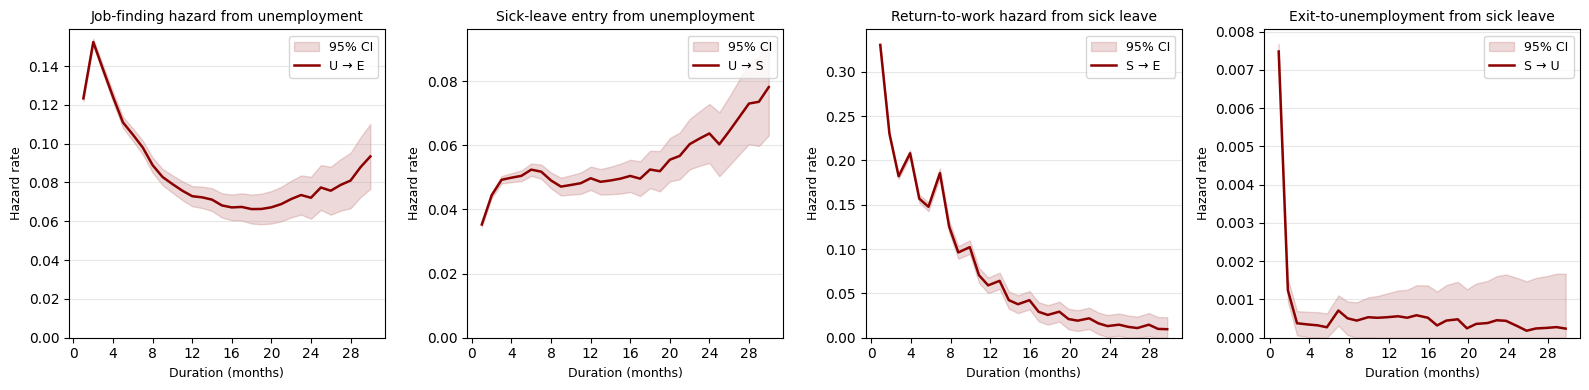

In [26]:
PANELS = [
    (_ue, 'U → E', 'Job-finding hazard from unemployment'),
    (_us, 'U → S', 'Sick-leave entry from unemployment'),
    (_se, 'S → E', 'Return-to-work hazard from sick leave'),
    (_su, 'S → U', 'Exit-to-unemployment from sick leave'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (_df, label, title) in zip(axes, PANELS):
    d  = _df['duration'].values
    h  = _df['hazard'].values
    lo = _df['hazard_lower'].values
    hi = _df['hazard_upper'].values

    ax.fill_between(d, lo, hi, color='darkred', alpha=0.15, label='95% CI')
    ax.plot(d, h, '-', color='darkred', lw=1.8, ms=4, label=label)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Duration (months)', fontsize=9)
    ax.set_ylabel('Hazard rate', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig('hazard_data.pdf', bbox_inches='tight')
plt.show()